# Week 6 - Bivariate Analysis, part 2

# 1. Lesson: no lesson this week

# 2. Weekly graph question

Suppose you wanted to show the nitrate and phosphate level in a water sample.  What are the advantages and disadvantages of showing this as an area plot, as opposed to two separate line graphs?  How would you adjust the graphs shown to improve the presentation?

In [1]:
import numpy as np
import seaborn as sns
import pandas as pd

Text(0, 0.5, 'Nitrate level (% of eutrophic value)')

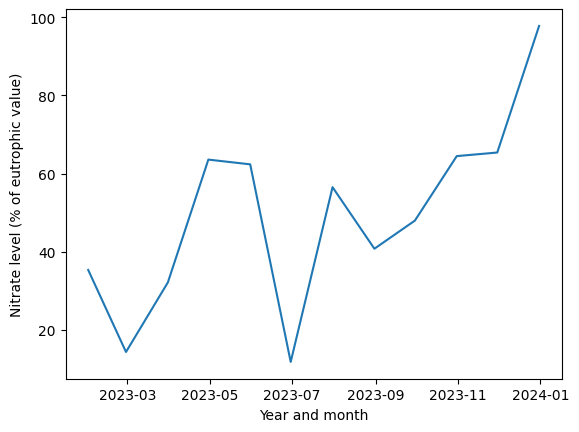

In [3]:
numdates = 12
np.random.seed(0)
time_series = 100 * (np.random.normal(size = numdates) / 5 + np.arange(numdates) / 16)
datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='ME')
ax = sns.lineplot(x = datearray, y = time_series)
ax.set_xlabel("Year and month")
ax.set_ylabel("Nitrate level (% of eutrophic value)")

Text(0, 0.5, 'Phosphate level (% of eutrophic value)')

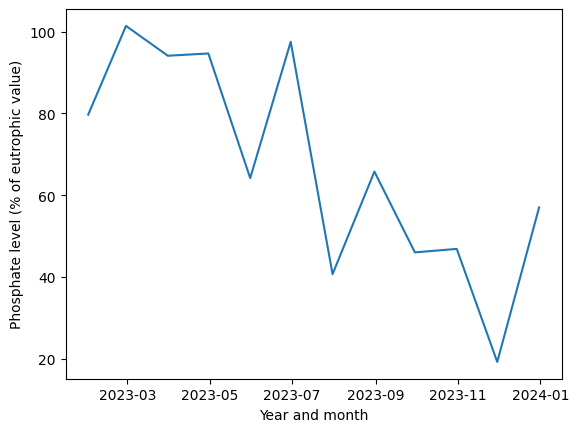

In [5]:
np.random.seed(1)
time_series_2 =  100 * (1 - (np.random.normal(size = numdates) / 8 + np.arange(numdates) / 16))
datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='ME')
ax = sns.lineplot(x = datearray, y = time_series_2)
ax.set_xlabel("Year and month")
ax.set_ylabel("Phosphate level (% of eutrophic value)")

<Axes: >

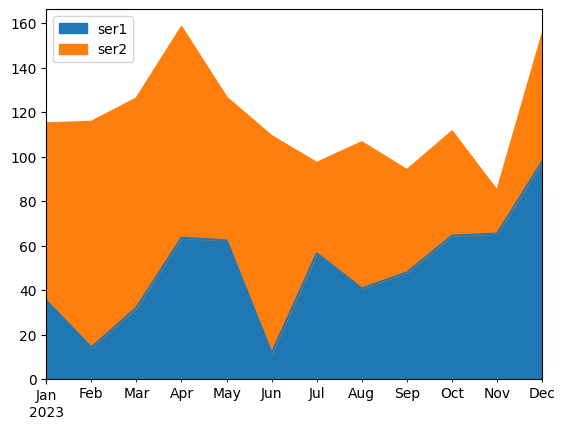

In [6]:
df = pd.DataFrame({'ser1': time_series, 'ser2': time_series_2}, index = datearray)
df.plot.area()

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

### Here are some types of analysis you can do:

- Find correlations between pairs of variables.

- Draw scatterplots, especially when the correlation is large.

- Draw pairplots.

- Draw line graphs and/or area graphs when there is date or time data together with numerical data.

### Conclusions:

- Explain what conclusions you would draw from this analysis: are the data what you expect?  Are the data likely to be usable?  If the data are not useable, find some new data!

- Do you see any outliers?  (Data points that are far from the rest of the data).

- Are any data items highly correlated with each other, suggesting that they are redundant?

- For the line plots, do you see a trend or pattern over time?  Does this suggest that the data are changing over time (drifting) in such a way as to invalidate comparisons?

- Can you think of any confounding variables?  (Third variables that could explain any correlations between other variables.  These third variables may or may not be reported in the dataset.)

In [22]:
# Import dataset
df_cyber_events = pd.read_csv('cyber_events_database.csv', encoding='ISO-8859-1', dtype={'change_log': str})
df_cyber_events.info()

<class 'pandas.DataFrame'>
RangeIndex: 16532 entries, 0 to 16531
Data columns (total 46 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   slug                16532 non-null  str  
 1   original_method     16532 non-null  int64
 2   event_date          16532 non-null  str  
 3   reported_date       1977 non-null   str  
 4   year                16532 non-null  int64
 5   month               16532 non-null  int64
 6   actor               16532 non-null  str  
 7   actor_type          16532 non-null  str  
 8   organization        16532 non-null  str  
 9   industry_code       16532 non-null  int64
 10  industry            16532 non-null  str  
 11  motive              16532 non-null  str  
 12  event_type          16532 non-null  str  
 13  event_subtype       16532 non-null  str  
 14  magnitude           716 non-null    str  
 15  duration            692 non-null    str  
 16  scope               719 non-null    str  
 17  ip  

In [29]:
# Finding correlations

# Import
from scipy.stats import chi2_contingency

# Create a contingency table (cross-tabulation)
contingency_table = pd.crosstab(df_cyber_events['actor_type'], df_cyber_events['event_subtype'])
print("Contingency Table:")
print(contingency_table)

# Perform the Chi-square test
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print(f"\nChi-square statistic: {chi2}")
print(f"P-value: {p_value}")

# Interpret the result
alpha = 0.05
if p_value < alpha:
    print("Result: Reject the null hypothesis. There is a significant association between the variables.")
else:
    print("Result: Fail to reject the null hypothesis. There is no significant association between the variables.")

Contingency Table:
event_subtype  Data Attack  Data Attack,Exploitation Of Application Server  \
actor_type                                                                   
Criminal              2673                                               8   
Hacktivist              27                                               0   
Hobbyist                 5                                               0   
Nation-State           194                                               0   
Terrorist                0                                               0   
Undetermined            33                                               0   

event_subtype  Data Attack,Exploitation of  Network Infrastructure  \
actor_type                                                           
Criminal                                                       1     
Hacktivist                                                     0     
Hobbyist                                                       0     
Nation

# 4. Storytelling With Data plot

Reproduce any graph of your choice in p. 86-98 of the Storytelling With Data book as best you can.  (The second half of chapter three).  You do not have to get the exact data values right, just the overall look and feel.

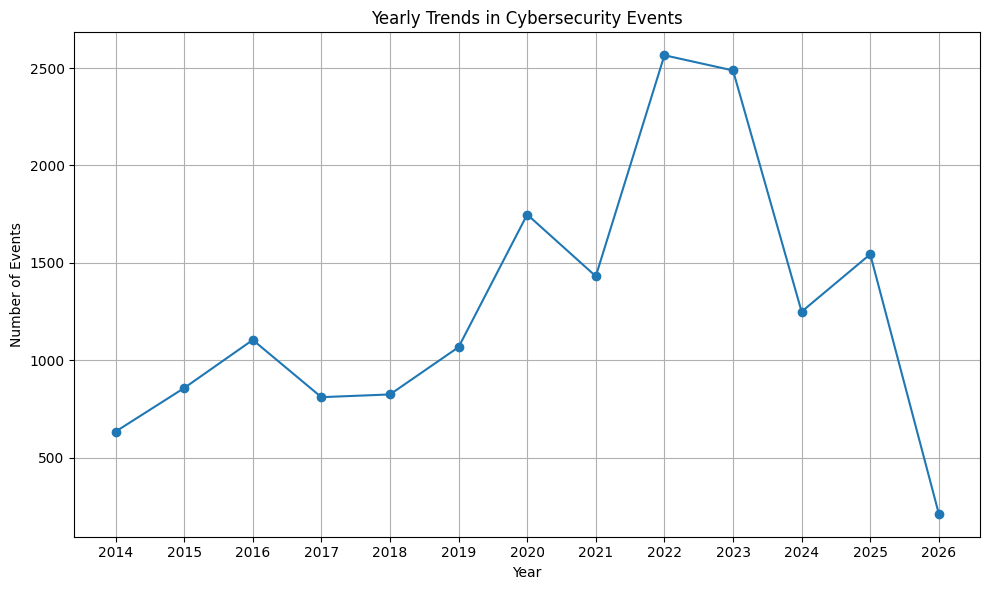

In [40]:
import matplotlib.pyplot as plt

# --- Data Preparation: Ensure the 'year' column is a numeric type ---
# This step is crucial if the year column was loaded as text or contains 'NA' values
df_cyber_events['year'] = pd.to_numeric(df_cyber_events['year'], errors='coerce')

# Drop any rows where the year could not be converted (is NaN)
df_cyber_events.dropna(subset=['year'], inplace=True)

# Convert 'year' to integer type
# --- 2. Data Preparation: Ensure the 'year' column is a numeric type ---
# This step is crucial if the year column was loaded as text or contains 'NA' values
df_cyber_events['year'] = pd.to_numeric(df_cyber_events['year'], errors='coerce')

# Drop any rows where the year could not be converted (is NaN)
df_cyber_events.dropna(subset=['year'], inplace=True)

# Convert 'year' to integer type
df_cyber_events['year'] = df_cyber_events['year'].astype(int)


# --- 3. Aggregate data to count events per year ---
yearly_trends = df_cyber_events.groupby('year').size().reset_index(name='event_count')


# --- 4. Produce the graph using matplotlib ---
plt.figure(figsize=(10, 6))
plt.plot(yearly_trends['year'], yearly_trends['event_count'], marker='o', linestyle='-')

plt.title('Yearly Trends in Cybersecurity Events')
plt.xlabel('Year')
plt.ylabel('Number of Events')
plt.grid(True)
plt.xticks(yearly_trends['year']) # Ensure all relevant years are shown on the x-axis
plt.tight_layout()

# Display the plot in the Jupyter notebook
plt.show()